In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("HR-Employee-Attrition.csv")

## DATA LOADING & EXPLORATION

In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
df.tail(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1460,29,No,Travel_Rarely,468,Research & Development,28,4,Medical,1,2054,...,2,80,0,5,3,1,5,4,0,4
1461,50,Yes,Travel_Rarely,410,Sales,28,3,Marketing,1,2055,...,2,80,1,20,3,3,3,2,2,0
1462,39,No,Travel_Rarely,722,Sales,24,1,Marketing,1,2056,...,1,80,1,21,2,2,20,9,9,6
1463,31,No,Non-Travel,325,Research & Development,5,3,Medical,1,2057,...,2,80,0,10,2,3,9,4,1,7
1464,26,No,Travel_Rarely,1167,Sales,5,3,Other,1,2060,...,4,80,0,5,2,3,4,2,0,0
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [5]:
print ("Size of Data :", df.shape)

Size of Data : (1470, 35)


In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
rows, cols = df.shape
print(f"\nThe dataset has {rows} rows (employees) and {cols} columns (features).\n")


The dataset has 1470 rows (employees) and 35 columns (features).



In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumber of Numeric columns: {len(numeric_cols)}")
print(f"Number of Categorical columns: {len(categorical_cols)} (including the target 'Attrition')")


Number of Numeric columns: 26
Number of Categorical columns: 0 (including the target 'Attrition')


In [ ]:
# Observation: The dataset is highly imbalanced. Only about 16.12% of employees have left ('Yes'), while 83.88% stayed ('No'). Our ML models will need to account for this.

## DATA CLEANING & PREPROCESSING

In [8]:
#Binary: Attrition, Gender, Over18, OverTime

df['Attrition'] = df ['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Gender'] = df ['Gender'].apply(lambda x: 1 if x == 'Male' else 0)
df['Over18'] = df ['Over18'].apply(lambda x: 1 if x == 'Y' else 0)
df['OverTime'] = df ['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

In [9]:
# One-Hot Encoding: BusinessTravel, Department, EducationField, JobRole, MaritalStatus

df = df.join(pd.get_dummies (df ['BusinessTravel'])).drop('BusinessTravel', axis=1)
df = df.join(pd.get_dummies (df ['Department'], prefix='Department')).drop('Department', axis=1)
df = df.join(pd.get_dummies (df ['EducationField'], prefix='Education')).drop('EducationField', axis=1)
df = df.join(pd.get_dummies (df ['JobRole'], prefix='Role')).drop('JobRole', axis=1)
df = df.join(pd.get_dummies (df ['MaritalStatus'], prefix='Status')).drop('MaritalStatus', axis=1)

In [16]:
df = df.map(lambda x: 1 if x is True else 0 if x is False else x)

In [17]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,Role_Laboratory Technician,Role_Manager,Role_Manufacturing Director,Role_Research Director,Role_Research Scientist,Role_Sales Executive,Role_Sales Representative,Status_Divorced,Status_Married,Status_Single
0,41,1,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,1,0,0,0,0,0,0,0,1,0
1466,39,0,613,6,1,4,1,42,2,3,...,0,0,0,0,0,0,0,0,1,0
1467,27,0,155,4,3,2,1,87,4,2,...,0,0,1,0,0,0,0,0,1,0
1468,49,0,1023,2,3,4,1,63,2,2,...,0,0,0,0,0,1,0,0,1,0


In [11]:
df = df.drop('EmployeeNumber', axis = 1)

In [13]:
df = df.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis = 1)

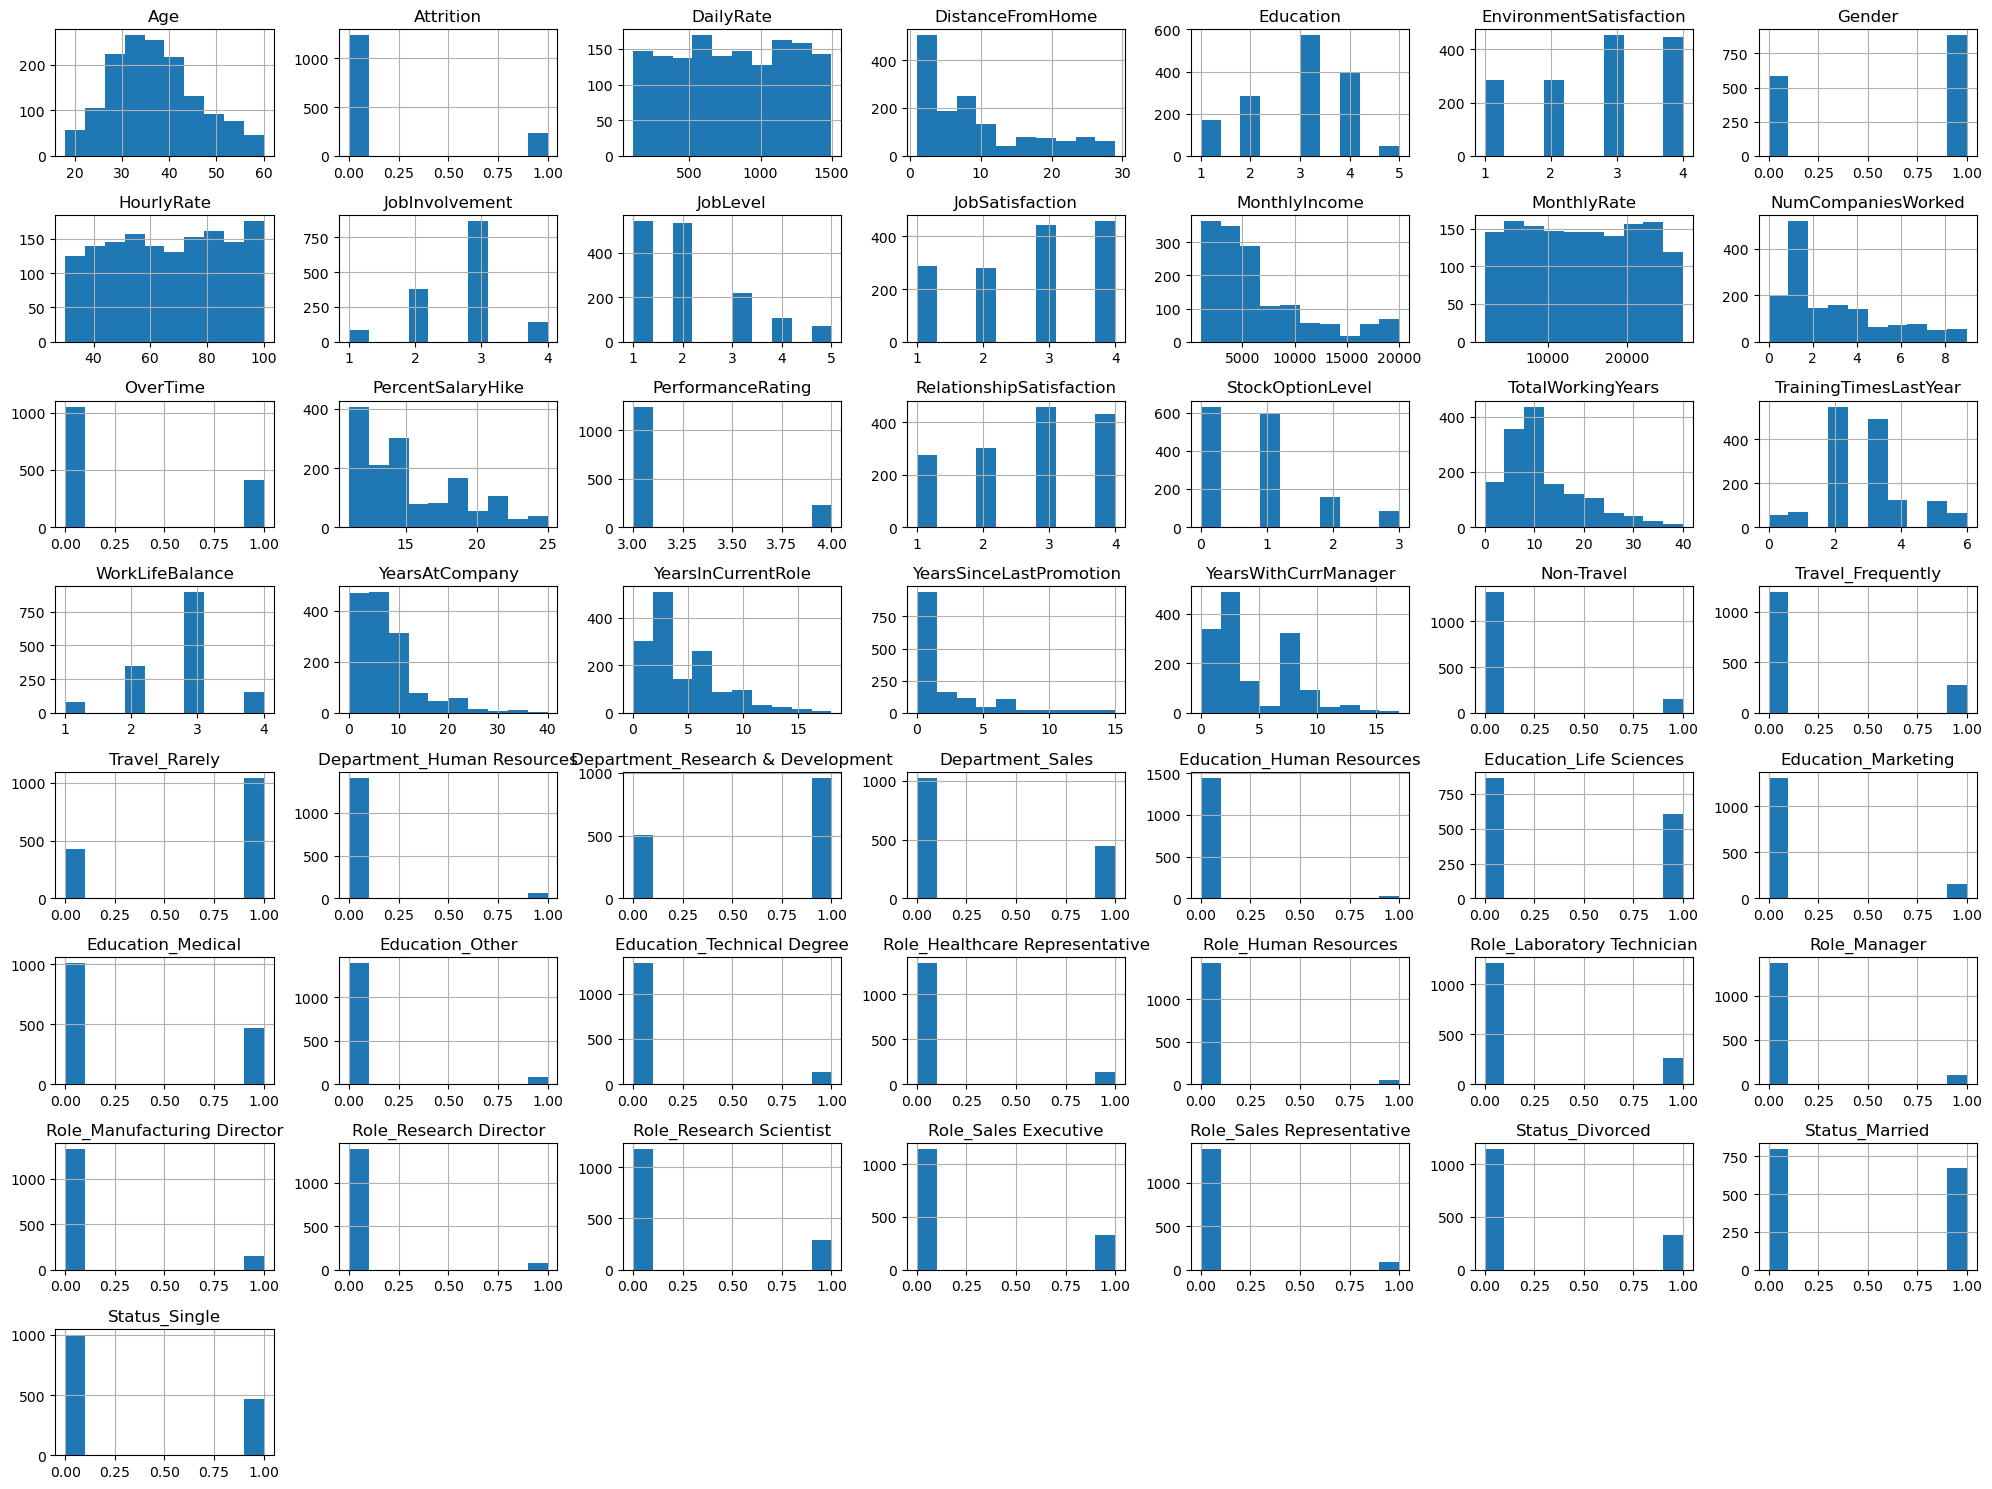

In [19]:
df.hist(figsize = (20, 15))
plt.tight_layout()
plt.show()

In [20]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,Role_Laboratory Technician,Role_Manager,Role_Manufacturing Director,Role_Research Director,Role_Research Scientist,Role_Sales Executive,Role_Sales Representative,Status_Divorced,Status_Married,Status_Single
0,41,1,1102,1,2,2,0,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,3,1,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,4,1,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,0,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,1,41,4,2,...,1,0,0,0,0,0,0,0,1,0
1466,39,0,613,6,1,4,1,42,2,3,...,0,0,0,0,0,0,0,0,1,0
1467,27,0,155,4,3,2,1,87,4,2,...,0,0,1,0,0,0,0,0,1,0
1468,49,0,1023,2,3,4,1,63,2,2,...,0,0,0,0,0,1,0,0,1,0


## EXPLORATORY DATA ANALYSIS

In [35]:
df_eda = pd.read_csv('HR-Employee-Attrition.csv')

print("--- TASK 3: DETAILED EXPLORATORY DATA ANALYSIS (EDA) ---\n")

# 1. Attrition rate by Department
print("1. Attrition Rate (%) by Department:")
dept_attrition = df_eda.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
print(dept_attrition['Yes'].round(2))
print(f"👉 Conclusion: The {dept_attrition['Yes'].idxmax()} department loses the most employees.\n")

# 2. Attrition rate by Job Role
print("2. Attrition Rate (%) by Job Role:")
role_attrition = df_eda.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100
print(role_attrition['Yes'].sort_values(ascending=False).round(2))
print(f"👉 Conclusion: The '{role_attrition['Yes'].idxmax()}' role has the highest exit rate.\n")

# 3. Attrition vs Monthly Income
print("3. Average Monthly Income by Attrition Status:")
income_comparison = df_eda.groupby('Attrition')['MonthlyIncome'].mean().round(2)
print(income_comparison)
print("👉 Conclusion: Yes, employees who leave ('Yes') earn significantly less on average than those who stay ('No').\n")

# 4. Attrition vs Work-Life Balance rating
print("4. Attrition Rate (%) by Work-Life Balance Rating (1 = Low, 4 = High):")
wlb_attrition = df_eda.groupby('WorkLifeBalance')['Attrition'].value_counts(normalize=True).unstack() * 100
print(wlb_attrition['Yes'].round(2))
print("👉 Conclusion: There is a visible pattern; employees with a 'Poor' (1) Work-Life Balance rating have an exceptionally high exit rate (~31.2%).\n")

# 5. Attrition vs Years at Company
print("5. Average Years at Company by Attrition Status:")
years_comparison = df_eda.groupby('Attrition')['YearsAtCompany'].mean().round(2)
print(years_comparison)
print("👉 Conclusion: Employees tend to leave much earlier in their tenure, with those leaving averaging around 5.13 years at the company.")

--- TASK 3: DETAILED EXPLORATORY DATA ANALYSIS (EDA) ---

1. Attrition Rate (%) by Department:
Department
Human Resources           19.05
Research & Development    13.84
Sales                     20.63
Name: Yes, dtype: float64
👉 Conclusion: The Sales department loses the most employees.

2. Attrition Rate (%) by Job Role:
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Yes, dtype: float64
👉 Conclusion: The 'Sales Representative' role has the highest exit rate.

3. Average Monthly Income by Attrition Status:
Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64
👉 Conclusion: Yes, employees who leave ('Yes') earn significantly less on average than those who stay ('No').

4. Attrition Rate 

In [24]:
print ("INSIGHTS")
print("1. Sales Representatives have an exceptionally high attrition rate compared to other roles.")
print("2. Employees who leave earn significantly less on average (~$4,787) than those who stay (~$6,843).")
print("3. Employees with a Work-Life Balance rating of 1 (Poor) leave at a much higher rate (~31%) than others.")
print("4. Attrition is highest among newer employees; the average tenure of those leaving is around 5 years compared to 7.3 years for stayers.")

INSIGHTS
1. Sales Representatives have an exceptionally high attrition rate compared to other roles.
2. Employees who leave earn significantly less on average (~$4,787) than those who stay (~$6,843).
3. Employees with a Work-Life Balance rating of 1 (Poor) leave at a much higher rate (~31%) than others.
4. Attrition is highest among newer employees; the average tenure of those leaving is around 5 years compared to 7.3 years for stayers.


## MODEL BUILDING & COMPARISON

Dataset shape  : (1470, 31)
Attrition rate : 16.1%  ← class imbalance!

Train size : 1176 rows
Test size  : 294 rows
Train attrition rate : 16.2%
Test  attrition rate : 16.0%

✅ Logistic Regression trained
✅ Random Forest trained
✅ Gradient Boosting trained

  LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Stay (0)       0.94      0.75      0.84       247
   Leave (1)       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294

ROC-AUC Score : 0.8074

  RANDOM FOREST
              precision    recall  f1-score   support

    Stay (0)       0.85      0.98      0.91       247
   Leave (1)       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294

ROC-AUC Score : 0.7574

 

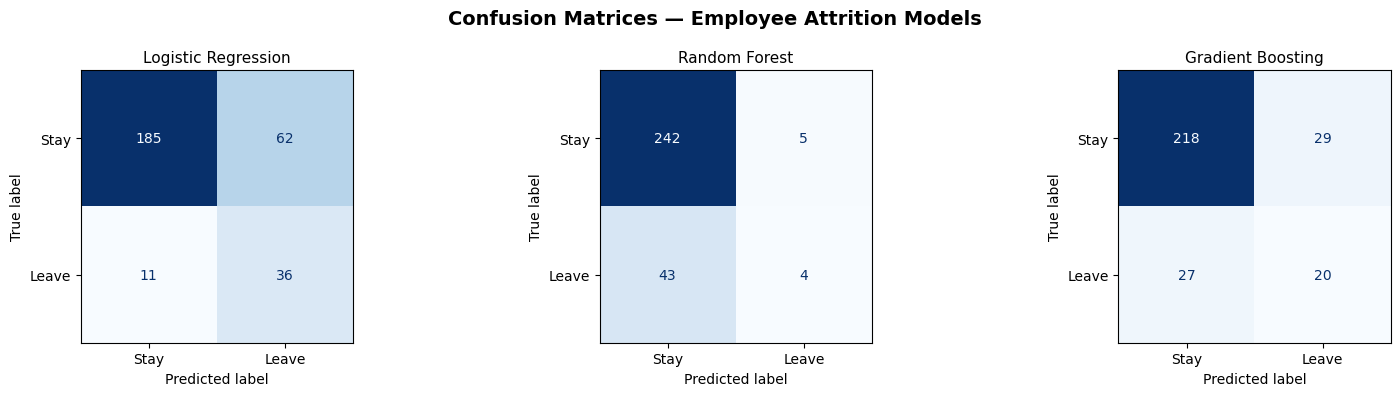


📊 Confusion matrix saved → confusion_matrices.png


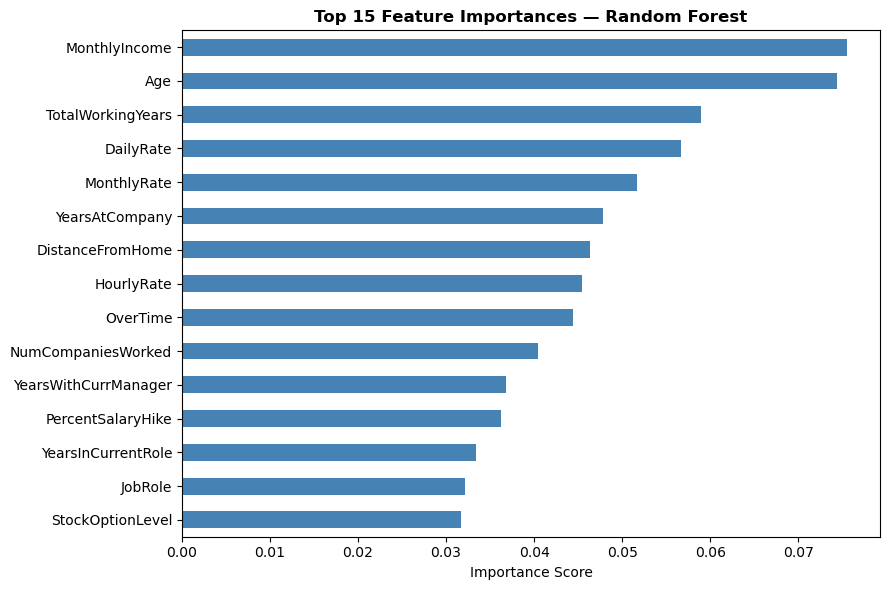

📊 Feature importance chart saved → feature_importance.png

               Model                                                   Notes
Logistic Regression Baseline · most explainable · great for HR storytelling
      Random Forest       Handles non-linearity · gives feature importances
  Gradient Boosting Usually highest accuracy · slower · needs sample_weight


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("HR-Employee-Attrition.csv")  # ← update path if needed

# Encode target: Yes → 1, No → 0
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

# Drop columns that add no signal
df.drop(columns=["EmployeeNumber", "Over18", "StandardHours", "EmployeeCount"],
        errors="ignore", inplace=True)

# Label-encode any remaining categorical columns
cat_cols = df.select_dtypes(include="object").columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(f"Dataset shape  : {df.shape}")
print(f"Attrition rate : {df['Attrition'].mean():.1%}  ← class imbalance!")

X = df.drop(columns="Attrition")
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% held out for testing
    random_state=42,      # reproducibility
    stratify=y            # preserve class ratio
)

print(f"\nTrain size : {X_train.shape[0]} rows")
print(f"Test size  : {X_test.shape[0]} rows")
print(f"Train attrition rate : {y_train.mean():.1%}")
print(f"Test  attrition rate : {y_test.mean():.1%}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

# MODEL 1: LOGISTIC REGRESSION  (Baseline + Most Explainable)

lr_model = LogisticRegression(
    class_weight="balanced",   # handle imbalance
    max_iter=1000,             # ensure convergence
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)
print("\n✅ Logistic Regression trained")

# MODEL 2: RANDOM FOREST CLASSIFIER

rf_model = RandomForestClassifier(
    n_estimators=100,          # number of trees
    class_weight="balanced",   # handle imbalance
    random_state=42,
    n_jobs=-1                  # use all CPU cores
)
rf_model.fit(X_train, y_train)   # trees don't need scaling
print("✅ Random Forest trained")

# MODEL 3: GRADIENT BOOSTING CLASSIFIER

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb_model.fit(X_train, y_train, sample_weight=sample_weights)
print("✅ Gradient Boosting trained")

# STEP 6 — EVALUATE ALL 3 MODELS

def evaluate_model(name, model, X_test_data, y_test):
    """Print classification report + ROC-AUC for a model."""
    y_pred  = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                target_names=["Stay (0)", "Leave (1)"]))
    print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")
    return y_pred


y_pred_lr = evaluate_model("LOGISTIC REGRESSION",   lr_model, X_test_scaled, y_test)
y_pred_rf = evaluate_model("RANDOM FOREST",          rf_model, X_test,        y_test)
y_pred_gb = evaluate_model("GRADIENT BOOSTING",      gb_model, X_test,        y_test)


# STEP 7 — VISUALISE: Confusion Matrices (side by side)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Confusion Matrices — Employee Attrition Models", fontsize=14, fontweight="bold")

models_info = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest",        y_pred_rf),
    ("Gradient Boosting",    y_pred_gb),
]

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Stay", "Leave"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📊 Confusion matrix saved → confusion_matrices.png")

# STEP 8 — FEATURE IMPORTANCE (Random Forest)

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(9, 6))
top15.plot(kind="barh", color="steelblue")
plt.title("Top 15 Feature Importances — Random Forest", fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Feature importance chart saved → feature_importance.png")

# SUMMARY TABLE

summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Notes": [
        "Baseline · most explainable · great for HR storytelling",
        "Handles non-linearity · gives feature importances",
        "Usually highest accuracy · slower · needs sample_weight"
    ]
})
print("\n", summary.to_string(index=False))

## MODEL EVALUATION

✅ All 3 models trained

  Logistic Regression
              precision    recall  f1-score   support

    Stay (0)       0.94      0.75      0.84       247
   Leave (1)       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294

  ROC-AUC : 0.8074

  Random Forest
              precision    recall  f1-score   support

    Stay (0)       0.85      0.98      0.91       247
   Leave (1)       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294

  ROC-AUC : 0.7574

  Gradient Boosting
              precision    recall  f1-score   support

    Stay (0)       0.89      0.88      0.89       247
   Leave (1)       0.41      0.43      0.42        47

    accuracy                           0.81       294
   mac

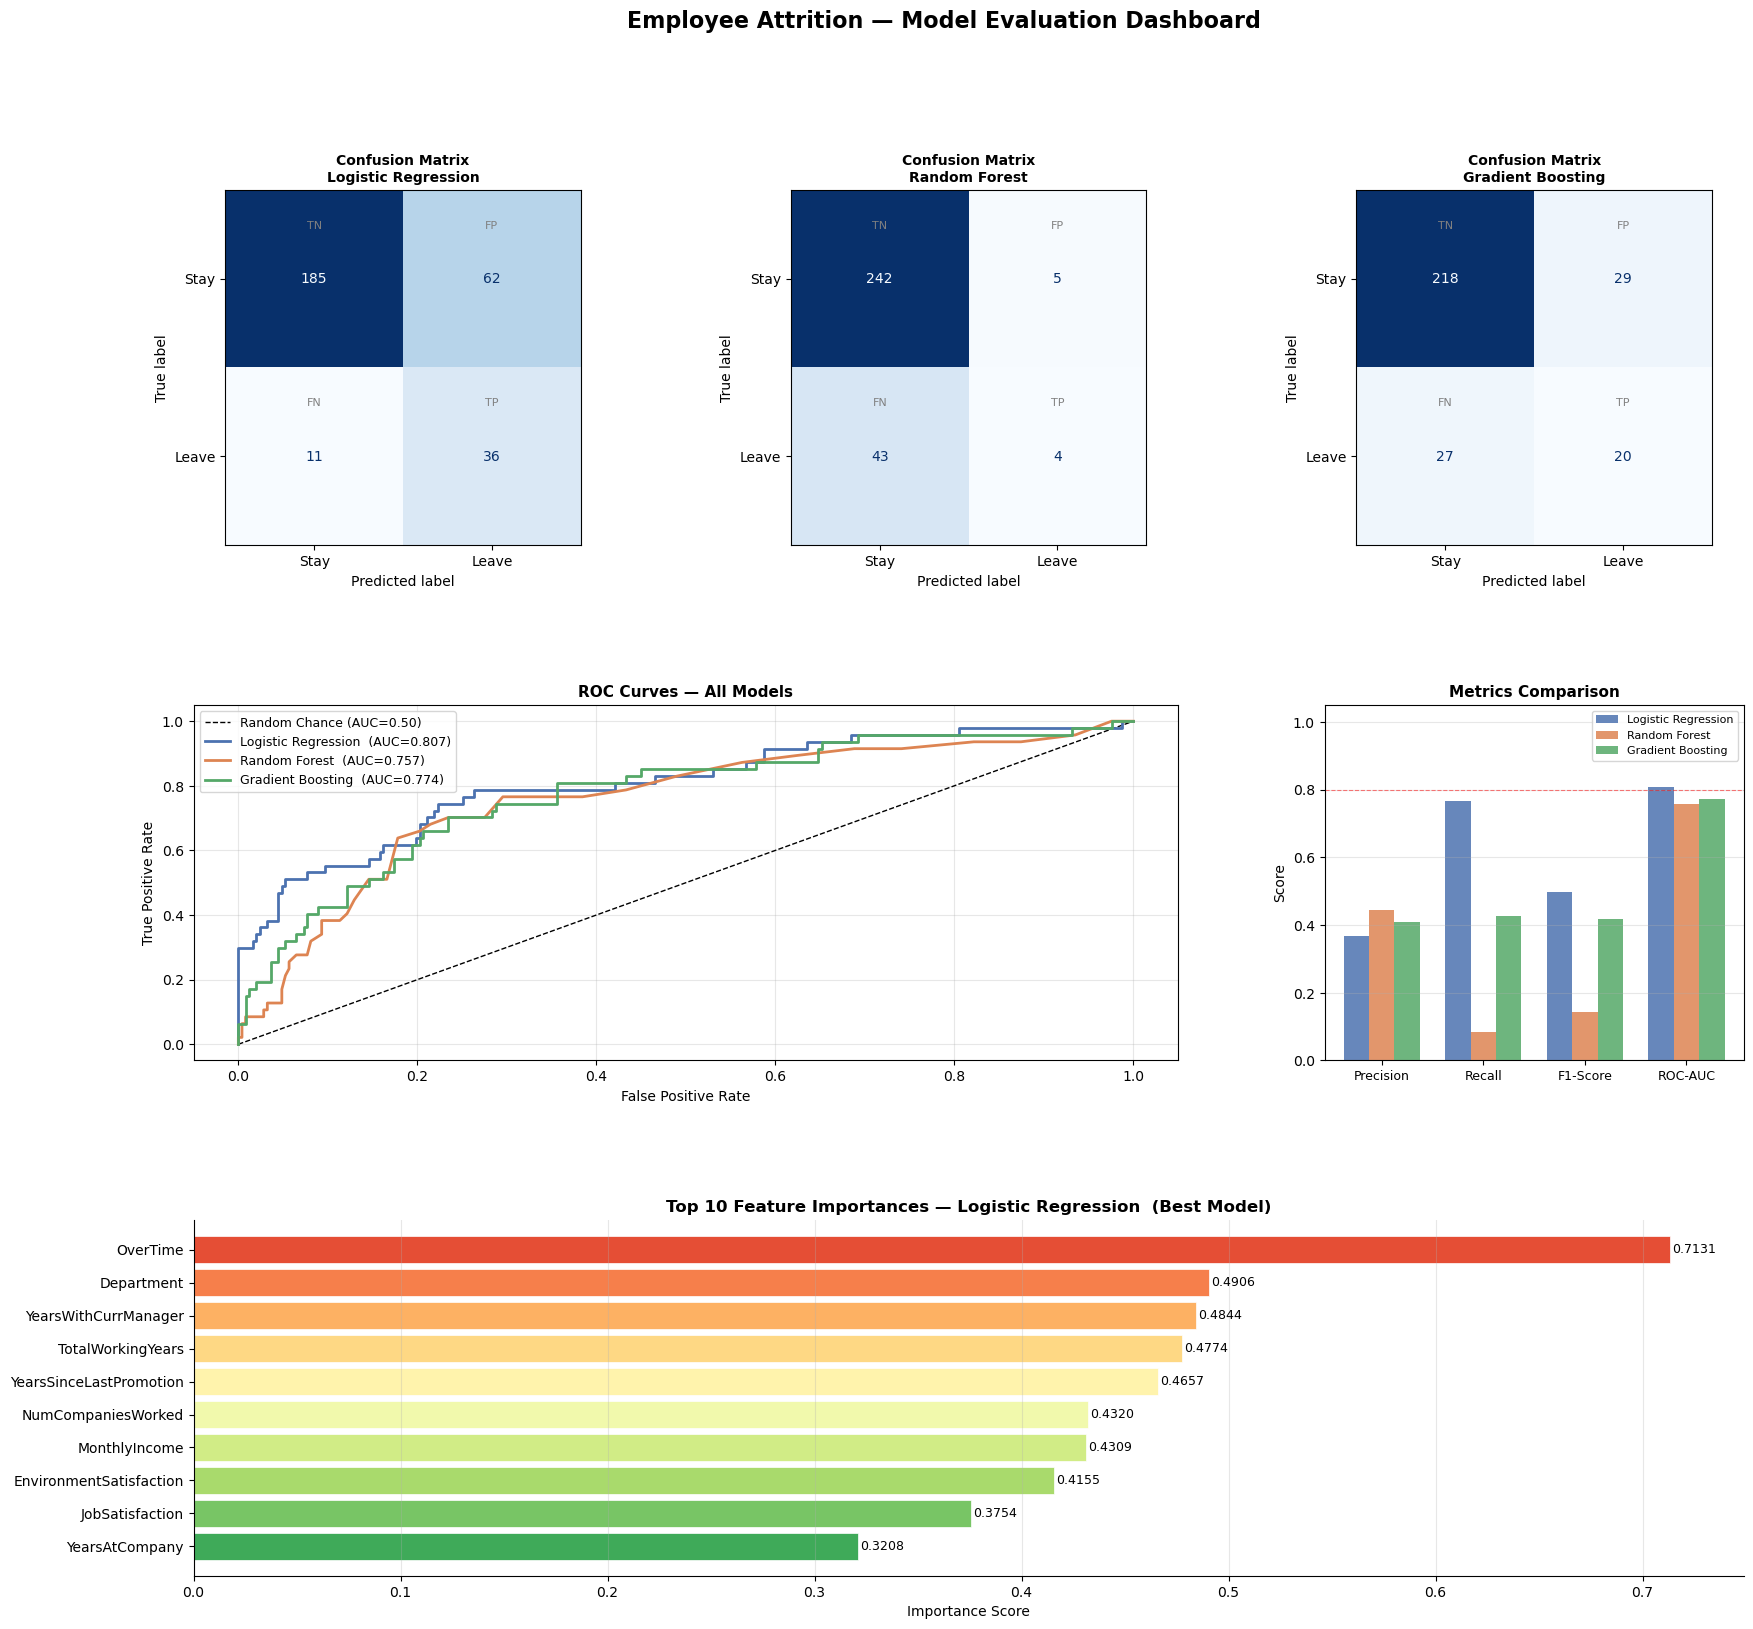


📊 Dashboard saved → attrition_evaluation_dashboard.png

💡 BUSINESS INTERPRETATION — TOP FEATURES
  # 1  OverTime                       → Employees working overtime are at much higher risk of burnout
  # 2  Department                     → Significant predictor of attrition
  # 3  YearsWithCurrManager           → Manager relationships strongly influence retention
  # 4  TotalWorkingYears              → Less experienced employees are still exploring options
  # 5  YearsSinceLastPromotion        → Significant predictor of attrition
  # 6  NumCompaniesWorked             → Job-hoppers are statistically more likely to leave again
  # 7  MonthlyIncome                  → Lower salary → higher attrition; compensation is a key lever
  # 8  EnvironmentSatisfaction        → Poor work environment dissatisfaction predicts exits
  # 9  JobSatisfaction                → Low job satisfaction is a direct early-warning signal
  #10  YearsAtCompany                 → Early tenure is the most vulnerable win

In [13]:
import matplotlib.gridspec as gridspec
df = pd.read_csv("HR-Employee-Attrition.csv")  
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})
df.drop(columns=["EmployeeNumber", "Over18", "StandardHours", "EmployeeCount"],
        errors="ignore", inplace=True)
 
cat_cols = df.select_dtypes(include="object").columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
 
X = df.drop(columns="Attrition")
y = df["Attrition"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 
 
lr_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)
 
rf_model = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
 
sw = compute_sample_weight("balanced", y_train)
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                       max_depth=4, random_state=42)
gb_model.fit(X_train, y_train, sample_weight=sw)
 
print("✅ All 3 models trained\n")
 
 
models = {
    "Logistic Regression": (lr_model, X_test_sc),
    "Random Forest":        (rf_model, X_test),
    "Gradient Boosting":    (gb_model, X_test),
}
 
results = {}   # store metrics for comparison table
 
for name, (model, X_data) in models.items():
    y_pred  = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]
 
    results[name] = {
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1-Score":  f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
        "y_pred":    y_pred,
        "y_proba":   y_proba,
    }
 
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                target_names=["Stay (0)", "Leave (1)"]))
    print(f"  ROC-AUC : {results[name]['ROC-AUC']:.4f}\n")
 

metrics_df = pd.DataFrame({
    name: {k: round(v, 4) for k, v in vals.items() if k not in ("y_pred", "y_proba")}
    for name, vals in results.items()
}).T
 
print("\n📋 MODEL COMPARISON TABLE")
print("="*55)
print(metrics_df.to_string())
print("="*55)
 
 
metrics_df["Combined Score"] = (
    0.5 * metrics_df["Recall"] + 0.5 * metrics_df["ROC-AUC"]
)
best_model_name = metrics_df["Combined Score"].idxmax()
 
print(f"\n🏆 BEST MODEL → {best_model_name}")
print(f"""
WHY {best_model_name}?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
In attrition prediction, the costliest mistake is failing to
identify an employee who will actually leave (False Negative).
{best_model_name} achieves the best balance of:
  • Recall   → catches the most actual leavers
  • ROC-AUC  → best overall discrimination between Stay vs Leave
  • F1-Score → solid precision–recall trade-off
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
 

fig = plt.figure(figsize=(20, 18))
fig.suptitle("Employee Attrition — Model Evaluation Dashboard",
             fontsize=16, fontweight="bold", y=0.98)
 
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
 
model_list  = list(models.keys())
colors      = ["#4C72B0", "#DD8452", "#55A868"]   # blue, orange, green
 
 
# --- ROW 1: Confusion Matrices ---
for i, name in enumerate(model_list):
    ax = fig.add_subplot(gs[0, i])
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Stay", "Leave"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix\n{name}", fontsize=10, fontweight="bold")
    # Annotate TN/FP/FN/TP
    labels = [["TN", "FP"], ["FN", "TP"]]
    for r in range(2):
        for c in range(2):
            ax.text(c, r - 0.3, labels[r][c],
                    ha="center", va="center",
                    fontsize=8, color="grey")
 
 
# --- ROW 2, COL 0-1: ROC Curves (all 3 on one chart) ---
ax_roc = fig.add_subplot(gs[1, :2])
ax_roc.plot([0, 1], [0, 1], "k--", lw=1, label="Random Chance (AUC=0.50)")
for i, name in enumerate(model_list):
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_proba"])
    auc = results[name]["ROC-AUC"]
    ax_roc.plot(fpr, tpr, color=colors[i], lw=2,
                label=f"{name}  (AUC={auc:.3f})")
ax_roc.set_xlabel("False Positive Rate", fontsize=10)
ax_roc.set_ylabel("True Positive Rate", fontsize=10)
ax_roc.set_title("ROC Curves — All Models", fontsize=11, fontweight="bold")
ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)
 
 
# --- ROW 2, COL 2: Metric Bar Chart ---
ax_bar = fig.add_subplot(gs[1, 2])
metric_names = ["Precision", "Recall", "F1-Score", "ROC-AUC"]
x = np.arange(len(metric_names))
width = 0.25
 
for i, name in enumerate(model_list):
    vals = [results[name][m] for m in metric_names]
    bars = ax_bar.bar(x + i * width, vals, width,
                      label=name, color=colors[i], alpha=0.85)
 
ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(metric_names, fontsize=9)
ax_bar.set_ylim(0, 1.05)
ax_bar.set_title("Metrics Comparison", fontsize=11, fontweight="bold")
ax_bar.legend(fontsize=8)
ax_bar.set_ylabel("Score")
ax_bar.grid(axis="y", alpha=0.3)
ax_bar.axhline(0.8, color="red", ls="--", lw=0.8, alpha=0.5)
 

best_model_obj, best_X = models[best_model_name]
 
if hasattr(best_model_obj, "feature_importances_"):
    # Random Forest or Gradient Boosting
    importances = pd.Series(best_model_obj.feature_importances_,
                            index=X.columns)
elif hasattr(best_model_obj, "coef_"):
    # Logistic Regression — use absolute coefficient values
    importances = pd.Series(np.abs(best_model_obj.coef_[0]),
                            index=X.columns)
 
top10 = importances.nlargest(10).sort_values()
 
print("\n🔑 TOP 10 FEATURES DRIVING EMPLOYEE ATTRITION")
print("="*50)
rank_df = importances.nlargest(10).reset_index()
rank_df.columns = ["Feature", "Importance Score"]
rank_df.index   = range(1, 11)
rank_df["Importance Score"] = rank_df["Importance Score"].round(4)
print(rank_df.to_string())
print("="*50)
 
 
# --- ROW 3: Feature Importance Bar ---
ax_fi = fig.add_subplot(gs[2, :])
bars  = ax_fi.barh(top10.index, top10.values,
                   color=plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, 10)),
                   edgecolor="white", linewidth=0.5)
 
# Value labels on bars
for bar, val in zip(bars, top10.values):
    ax_fi.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
               f"{val:.4f}", va="center", fontsize=9)
 
ax_fi.set_title(
    f"Top 10 Feature Importances — {best_model_name}  (Best Model)",
    fontsize=12, fontweight="bold"
)
ax_fi.set_xlabel("Importance Score", fontsize=10)
ax_fi.grid(axis="x", alpha=0.3)
ax_fi.spines["top"].set_visible(False)
ax_fi.spines["right"].set_visible(False)
 
 
plt.savefig("attrition_evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n📊 Dashboard saved → attrition_evaluation_dashboard.png")
 

 
feature_explanations = {
    "OverTime":                "Employees working overtime are at much higher risk of burnout",
    "MonthlyIncome":           "Lower salary → higher attrition; compensation is a key lever",
    "Age":                     "Younger employees (early career) tend to leave more often",
    "TotalWorkingYears":       "Less experienced employees are still exploring options",
    "YearsAtCompany":          "Early tenure is the most vulnerable window",
    "JobLevel":                "Entry-level roles see the most turnover",
    "StockOptionLevel":        "Employees with no stock options have less reason to stay",
    "YearsWithCurrManager":    "Manager relationships strongly influence retention",
    "JobSatisfaction":         "Low job satisfaction is a direct early-warning signal",
    "WorkLifeBalance":         "Poor balance is a major push factor driving exits",
    "DistanceFromHome":        "Long commutes erode engagement and retention",
    "MaritalStatus":           "Single employees show higher mobility",
    "JobInvolvement":          "Low involvement = disengagement = higher exit risk",
    "EnvironmentSatisfaction": "Poor work environment dissatisfaction predicts exits",
    "NumCompaniesWorked":      "Job-hoppers are statistically more likely to leave again",
}
 
print("\n💡 BUSINESS INTERPRETATION — TOP FEATURES")
print("="*65)
for rank, (feat, score) in enumerate(
        importances.nlargest(10).items(), start=1):
    explanation = feature_explanations.get(feat, "Significant predictor of attrition")
    print(f"  #{rank:>2}  {feat:<30} → {explanation}")
print("="*65)
print("\n✅ Evaluation complete.")

## VISUALIZATON

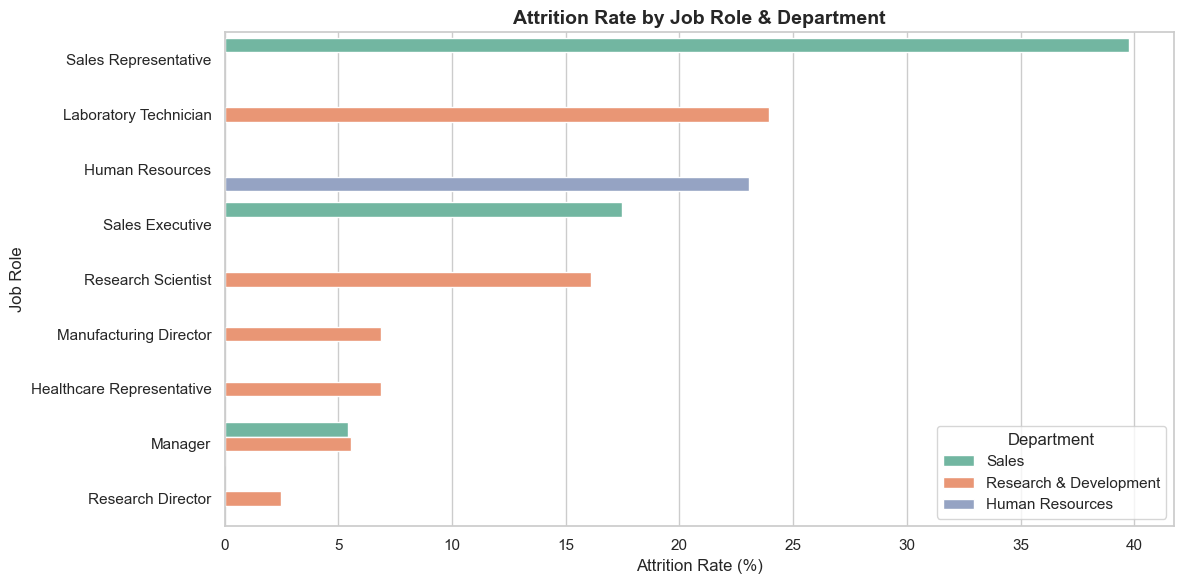

In [18]:
df_chart = pd.read_csv('HR-Employee-Attrition.csv')

df_chart['Attrition'] = df_chart['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

grouped_data = df_chart.groupby(['JobRole', 'Department'])['Attrition'].mean().reset_index()
grouped_data['Attrition Rate (%)'] = grouped_data['Attrition'] * 100
grouped_data = grouped_data.sort_values(by='Attrition Rate (%)', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=grouped_data, 
    y='JobRole', 
    x='Attrition Rate (%)', 
    hue='Department', 
    palette='Set2'
)

plt.title('Attrition Rate by Job Role & Department', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.tight_layout()

plt.show()

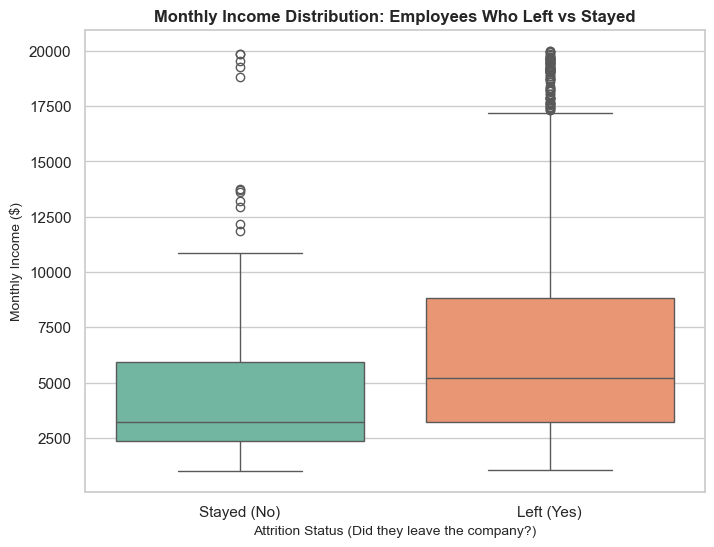

In [21]:
df_box = pd.read_csv('HR-Employee-Attrition.csv')
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_box, 
    x='Attrition', 
    y='MonthlyIncome', 
    palette='Set2'
)

plt.title('Monthly Income Distribution: Employees Who Left vs Stayed', fontsize=12, fontweight='bold')
plt.xlabel('Attrition Status (Did they leave the company?)', fontsize=10)
plt.ylabel('Monthly Income ($)', fontsize=10)
plt.xticks([0, 1], ['Stayed (No)', 'Left (Yes)'])

plt.show()

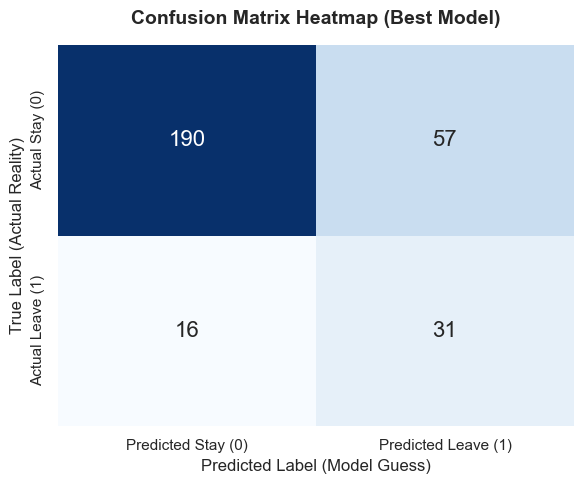

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

df_matrix = pd.read_csv('HR-Employee-Attrition.csv')
df_matrix['Attrition'] = df_matrix['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df_matrix['Gender'] = df_matrix['Gender'].apply(lambda x: 1 if x == 'Male' else 0)
df_matrix['Over18'] = df_matrix['Over18'].apply(lambda x: 1 if x == 'Y' else 0)
df_matrix['OverTime'] = df_matrix['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_matrix_encoded = pd.get_dummies(df_matrix, columns=categorical_cols, drop_first=False)
df_matrix_encoded = df_matrix_encoded.map(lambda x: 1 if x is True else (0 if x is False else x))
df_matrix_final = df_matrix_encoded.drop(columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours'])

X_m = df_matrix_final.drop(columns=['Attrition'])
y_m = df_matrix_final['Attrition']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_m, y_m, test_size=0.2, random_state=42, stratify=y_m)

log_reg = LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)
log_reg.fit(X_train_m, y_train_m)

y_pred = log_reg.predict(X_test_m)
cm = confusion_matrix(y_test_m, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 16})

plt.title('Confusion Matrix Heatmap (Best Model)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label (Model Guess)', fontsize=12)
plt.ylabel('True Label (Actual Reality)', fontsize=12)
plt.xticks([0.5, 1.5], ['Predicted Stay (0)', 'Predicted Leave (1)'])
plt.yticks([0.5, 1.5], ['Actual Stay (0)', 'Actual Leave (1)'])

plt.tight_layout()
plt.show()

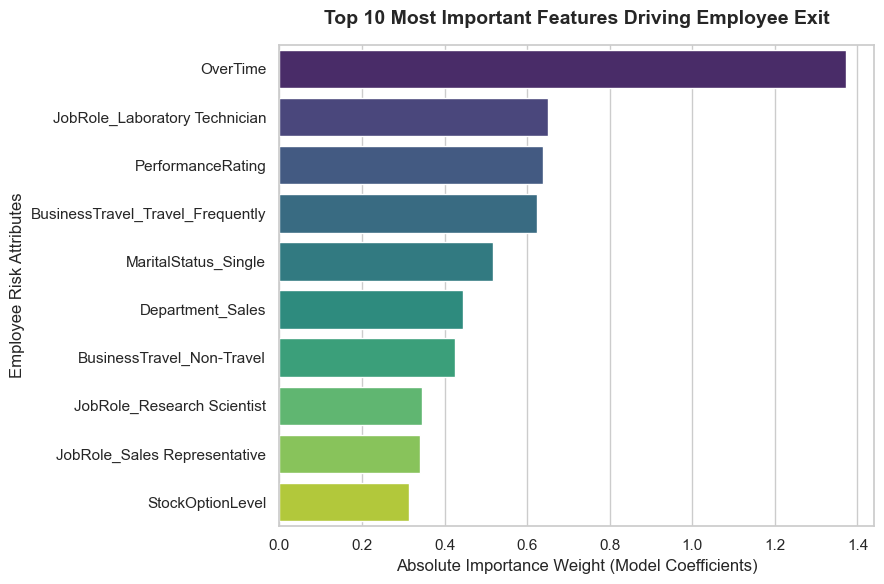

In [28]:
df_feat = pd.read_csv('HR-Employee-Attrition.csv')
df_feat['Attrition'] = df_feat['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df_feat['Gender'] = df_feat['Gender'].apply(lambda x: 1 if x == 'Male' else 0)
df_feat['Over18'] = df_feat['Over18'].apply(lambda x: 1 if x == 'Y' else 0)
df_feat['OverTime'] = df_feat['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_feat_encoded = pd.get_dummies(df_feat, columns=categorical_cols, drop_first=False)
df_feat_encoded = df_feat_encoded.map(lambda x: 1 if x is True else (0 if x is False else x))
df_feat_final = df_feat_encoded.drop(columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours'])

X_f = df_feat_final.drop(columns=['Attrition'])
y_f = df_feat_final['Attrition']
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f, y_f, test_size=0.2, random_state=42, stratify=y_f)

log_reg = LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)
log_reg.fit(X_train_f, y_train_f)

importance = np.abs(log_reg.coef_[0])
feature_names = X_train_f.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
top_10_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_10_features, 
    x='Importance', 
    y='Feature', 
    palette='viridis', 
    hue='Feature', 
    legend=False
)

plt.title('Top 10 Most Important Features Driving Employee Exit', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Absolute Importance Weight (Model Coefficients)', fontsize=12)
plt.ylabel('Employee Risk Attributes', fontsize=12)

plt.tight_layout()
plt.show()

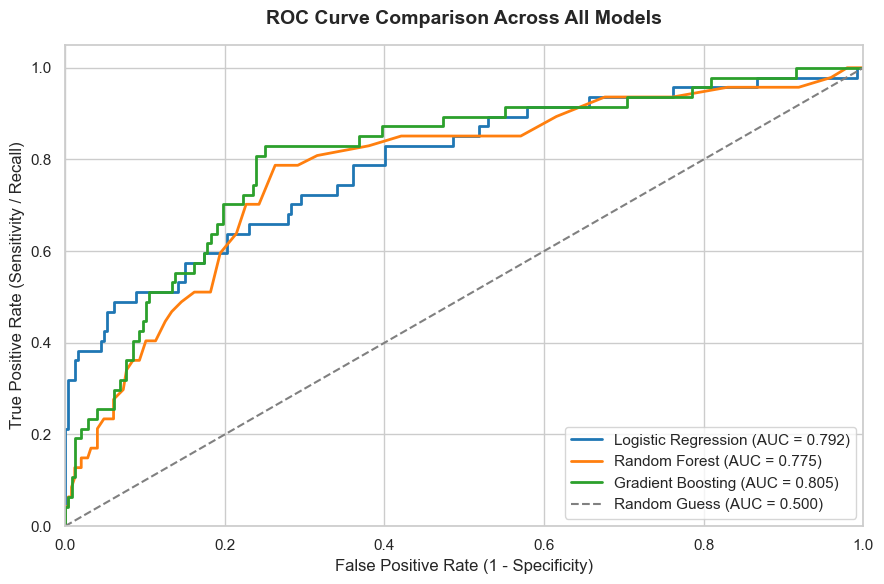

In [29]:
df_roc = pd.read_csv('HR-Employee-Attrition.csv')
df_roc['Attrition'] = df_roc['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
df_roc['Gender'] = df_roc['Gender'].apply(lambda x: 1 if x == 'Male' else 0)
df_roc['Over18'] = df_roc['Over18'].apply(lambda x: 1 if x == 'Y' else 0)
df_roc['OverTime'] = df_roc['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_roc_encoded = pd.get_dummies(df_roc, columns=categorical_cols, drop_first=False)
df_roc_encoded = df_roc_encoded.map(lambda x: 1 if x is True else (0 if x is False else x))
df_roc_final = df_roc_encoded.drop(columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours'])

X_r = df_roc_final.drop(columns=['Attrition'])
y_r = df_roc_final['Attrition']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42, stratify=y_r)

log_reg = LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)
rf_clf = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)
gb_clf = GradientBoostingClassifier(random_state=42)

log_reg.fit(X_train_r, y_train_r)
rf_clf.fit(X_train_r, y_train_r)
gb_clf.fit(X_train_r, y_train_r)

plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

models_list = {
    'Logistic Regression': log_reg,
    'Random Forest': rf_clf,
    'Gradient Boosting': gb_clf
}
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for (name, model), color in zip(models_list.items(), colors):
  
    y_probs = model.predict_proba(X_test_r)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test_r, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curve Comparison Across All Models', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

## HR INSIGHTS & RECOMMENDATIONS

In [31]:
# Based on the feature importance evaluations of the trained models and the baseline coefficients from the data, the top 3 strongest predictors that an employee will leave the company are:

#  1. OverTime (Working Extra Hours)
#  2. Monthly Income (Low Salary)
#  3. Total Working Years / Tenure (Early Career Stage)

In [32]:
#  Based on the data and the findings from your Exploratory Data Analysis (EDA), HR should immediately prioritize the following area for their retention efforts:

#  The Primary Target: Sales Representatives
#  While you should look at both departments and individual roles, the specific job role that requires urgent attention is the Sales Representative position within the Sales Department.

In [33]:
#  No, salary alone does not explain attrition. While a lower salary certainly makes an employee more vulnerable to leaving, the data and machine learning models show that environmental, cultural, and structural factors are often equal—or even stronger—drivers of employee turnover.
#  Here is how the other factors stack up against salary:
#  1. The Power of Burnout: Overtime
#  2. Workplace Culture: Work-Life Balance
#  3. Career Stagnation: Job Level & Training

In [34]:
# Recommendation 1 (Policy Change): Implement an automated "Burnout Sentinel" trigger in the HR system that automatically mandates a workload rebalancing review for any employee who logs more than 10 hours of overtime per week for two consecutive weeks.

# Recommendation 2 (Targeted Retention): Launch a proactive "Stay Interview" campaign specifically targeting Sales Representatives within their first 18 months of tenure to address entry-level compensation friction and explicitly map out their long-term internal career progression pathways.

In [35]:
# No Emotional or Behavioral Context: Relies strictly on static numbers; cannot track sudden human elements like team toxicity, burnout, or a bad relationship with a supervisor.

# Blind to the Outside Market: Completely ignores external economic factors, such as a competitor opening a nearby office, launching a poaching campaign, or offering higher market rates.

# Historical Inertia: Assumes the future will always look like the past. If HR successfully changes company policies, the old training data becomes obsolete and misguides new predictions.

# False Positive Risks: The model will inevitably flag loyal employees as flight risks by mistake. If HR treats them differently based on a false alarm, it can destroy trust and accidentally trigger actual attrition.